# Part I: Data Preparation - Surface Crack Classification

## Overview
This notebook handles the data preparation phase. We will:
1. Load the dataset from `Cracked` and `Non Cracked` folders
2. Describe the dataset
3. Visualize the data


### Import Libraries
Import all required libraries.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### Configure Dataset Paths

In [2]:
CRACKED_DIR = 'Cracked'
NON_CRACKED_DIR = 'Non Cracked'
print(f'Cracked dir exists: {os.path.exists(CRACKED_DIR)}')
print(f'Non Cracked dir exists: {os.path.exists(NON_CRACKED_DIR)}')

Cracked dir exists: True
Non Cracked dir exists: True


### Count Images Per Class

In [3]:
cracked_files = sorted(os.listdir(CRACKED_DIR))
non_cracked_files = sorted(os.listdir(NON_CRACKED_DIR))
n_cracked = len(cracked_files)
n_non_cracked = len(non_cracked_files)
total = n_cracked + n_non_cracked
print(f'Cracked: {n_cracked}')
print(f'Non-Cracked: {n_non_cracked}')
print(f'Total: {total}')
print(f'Cracked %: {n_cracked/total*100:.2f}%')
print(f'Non-Cracked %: {n_non_cracked/total*100:.2f}%')

Cracked: 28484
Non-Cracked: 67608
Total: 96092
Cracked %: 29.64%
Non-Cracked %: 70.36%


### Visualize Class Distribution

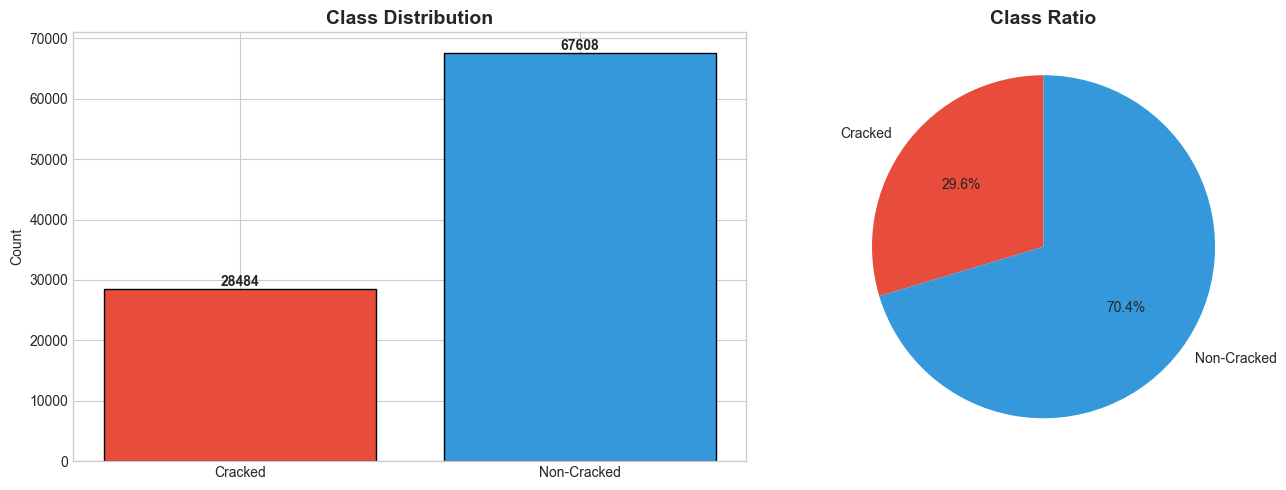

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = ['Cracked', 'Non-Cracked']
counts = [n_cracked, n_non_cracked]
colors = ['#e74c3c', '#3498db']
axes[0].bar(classes, counts, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v+500, str(v), ha='center', fontweight='bold')
axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Analyze Image Properties

In [5]:
sample_sizes = []
sample_modes = []
sample_sizes_list = []
sample = cracked_files[:50] + non_cracked_files[:50]
dirs = [CRACKED_DIR]*50 + [NON_CRACKED_DIR]*50
for fname, d in zip(sample, dirs):
    p = os.path.join(d, fname)
    sample_sizes_list.append(os.path.getsize(p))
    with Image.open(p) as img:
        sample_sizes.append(img.size)
        sample_modes.append(img.mode)
print('Dimensions:', dict(Counter(sample_sizes)))
print('Modes:', dict(Counter(sample_modes)))
print(f'File size - Min: {min(sample_sizes_list)}, Max: {max(sample_sizes_list)}, Mean: {np.mean(sample_sizes_list):.0f}')

Dimensions: {(227, 227): 100}
Modes: {'RGB': 100}
File size - Min: 2988, Max: 9205, Mean: 5536


### Sample Images - Cracked Class

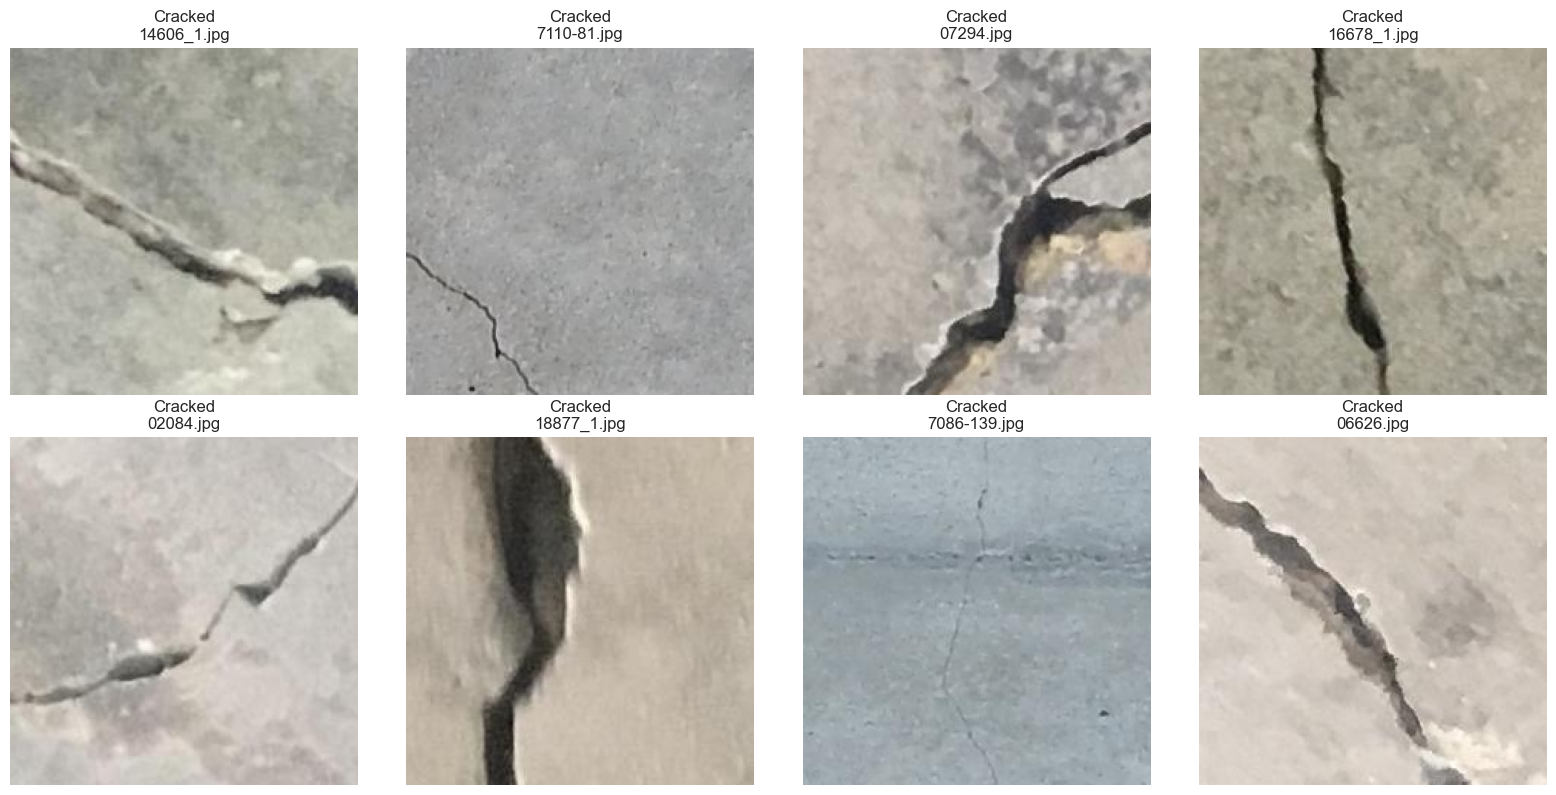

In [6]:
def plot_samples(class_dir, label, n=8):
    rng = np.random.RandomState(42)
    files = rng.choice(os.listdir(class_dir), n, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, f in enumerate(files):
        axes[i].imshow(Image.open(os.path.join(class_dir, f)))
        axes[i].set_title(f'{label}\n{f}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
plot_samples(CRACKED_DIR, 'Cracked')

### Sample Images - Non-Cracked Class

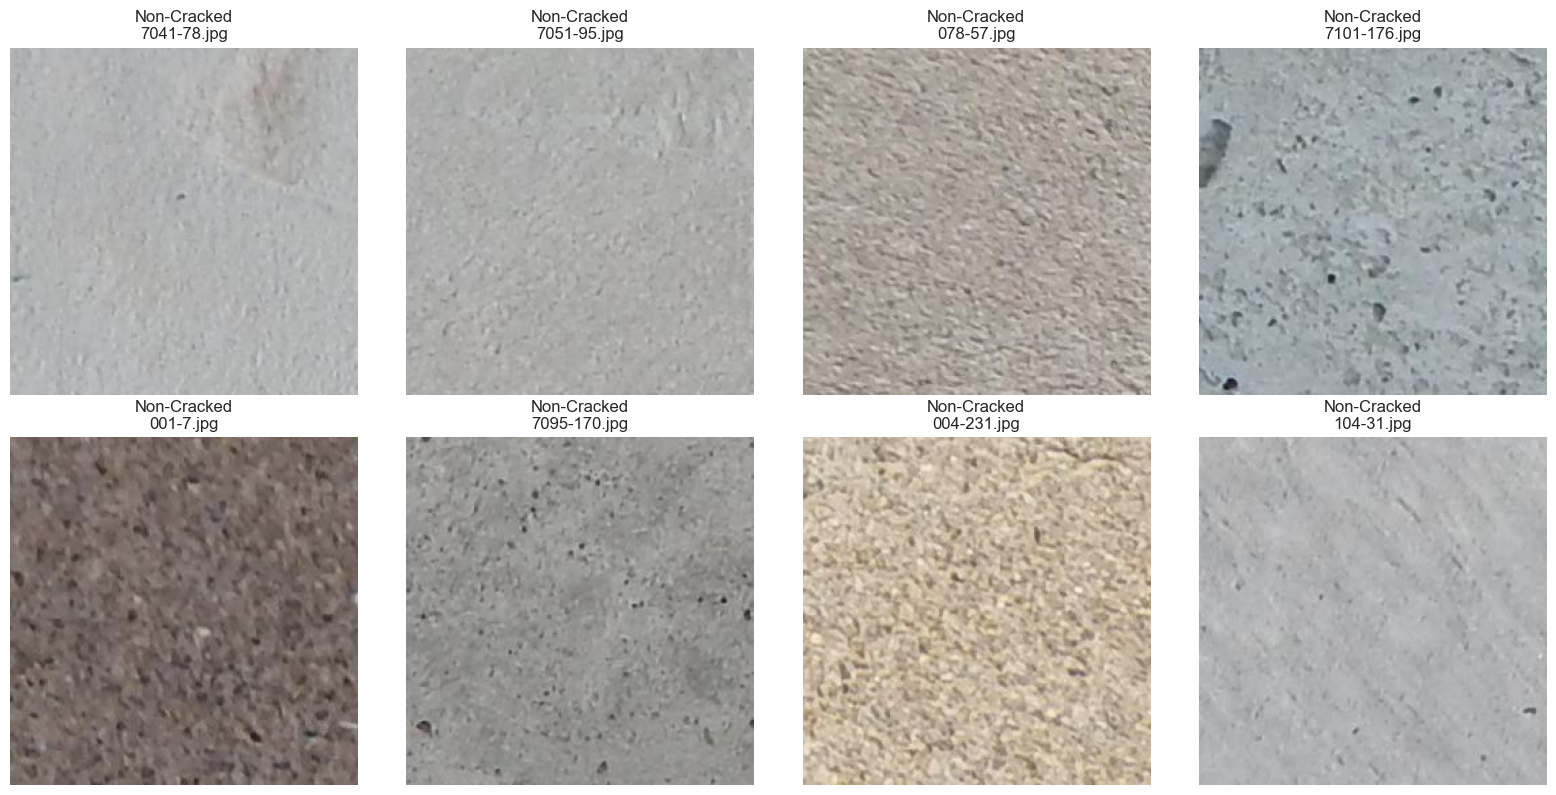

In [7]:
plot_samples(NON_CRACKED_DIR, 'Non-Cracked')

### Pixel Intensity Histograms by Class

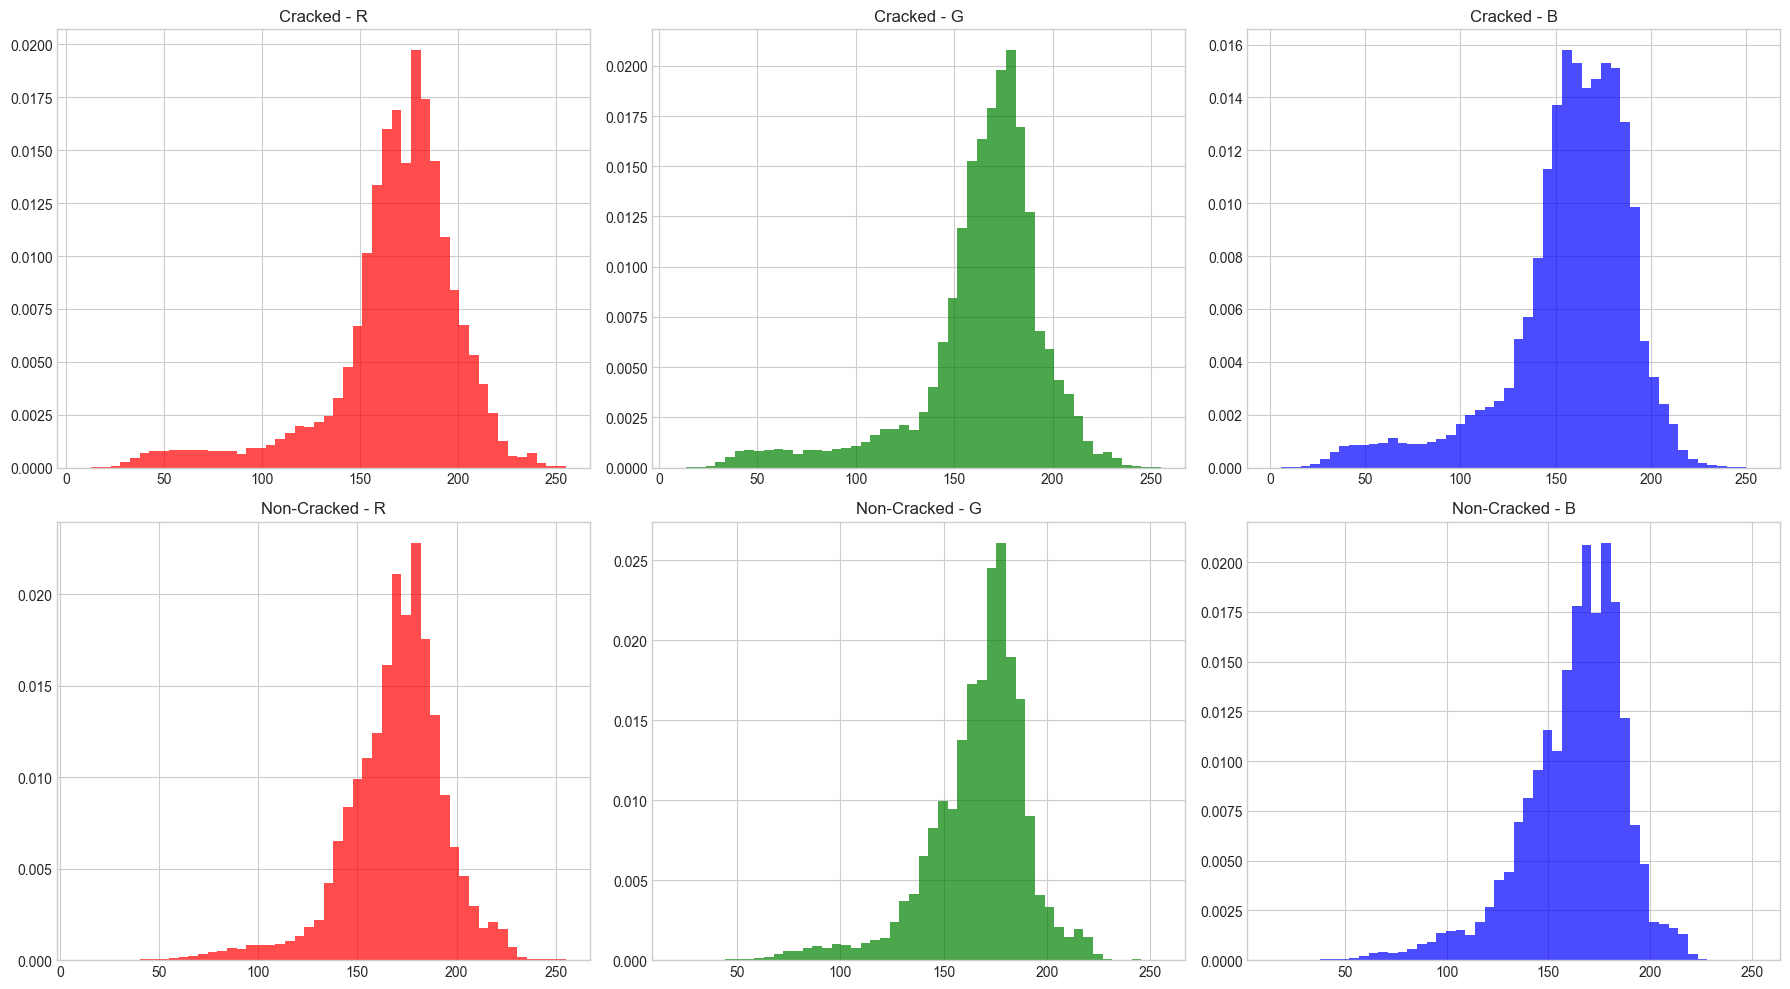

In [8]:
def channel_hists(class_dir, n=200):
    rng = np.random.RandomState(42)
    files = rng.choice(os.listdir(class_dir), n, replace=False)
    pixels = {'R': [], 'G': [], 'B': []}
    for f in files:
        arr = np.array(Image.open(os.path.join(class_dir, f)).resize((64,64)))
        pixels['R'].extend(arr[:,:,0].flatten())
        pixels['G'].extend(arr[:,:,1].flatten())
        pixels['B'].extend(arr[:,:,2].flatten())
    return {k: np.array(v) for k, v in pixels.items()}

cr_p = channel_hists(CRACKED_DIR)
nc_p = channel_hists(NON_CRACKED_DIR)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (ch, c) in enumerate(zip(['R','G','B'], ['red','green','blue'])):
    axes[0,i].hist(cr_p[ch], bins=50, alpha=0.7, color=c, density=True)
    axes[0,i].set_title(f'Cracked - {ch}')
    axes[1,i].hist(nc_p[ch], bins=50, alpha=0.7, color=c, density=True)
    axes[1,i].set_title(f'Non-Cracked - {ch}')
plt.tight_layout()
plt.show()

### Mean RGB Comparison Between Classes

C:\Users\bl7ax\AppData\Local\Temp\ipykernel_4408\3664718417.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([cr_m[:,i], nc_m[:,i]], labels=['Cracked','Non-Cracked'])
C:\Users\bl7ax\AppData\Local\Temp\ipykernel_4408\3664718417.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([cr_m[:,i], nc_m[:,i]], labels=['Cracked','Non-Cracked'])
C:\Users\bl7ax\AppData\Local\Temp\ipykernel_4408\3664718417.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([cr_m[:,i], nc_m[:,i]], labels=['Cracked','Non-Cracked'])


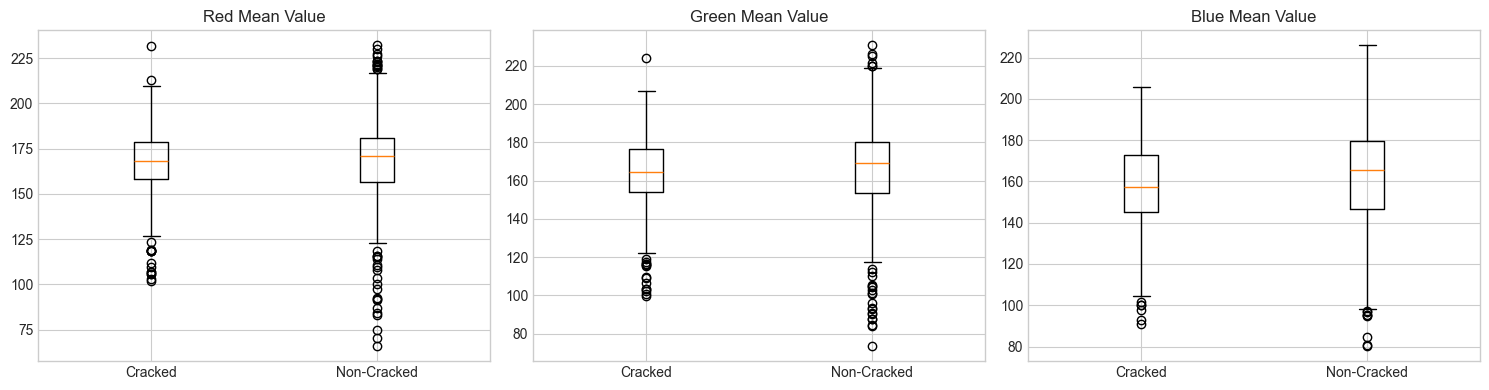

In [9]:
def mean_rgb(class_dir, n=500):
    rng = np.random.RandomState(42)
    files = rng.choice(os.listdir(class_dir), n, replace=False)
    vals = []
    for f in files:
        arr = np.array(Image.open(os.path.join(class_dir, f)).resize((64,64)))
        vals.append(arr.mean(axis=(0,1)))
    return np.array(vals)

cr_m = mean_rgb(CRACKED_DIR)
nc_m = mean_rgb(NON_CRACKED_DIR)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ch in enumerate(['Red','Green','Blue']):
    axes[i].boxplot([cr_m[:,i], nc_m[:,i]], labels=['Cracked','Non-Cracked'])
    axes[i].set_title(f'{ch} Mean Value')
plt.tight_layout()
plt.show()

### Average Images Per Class

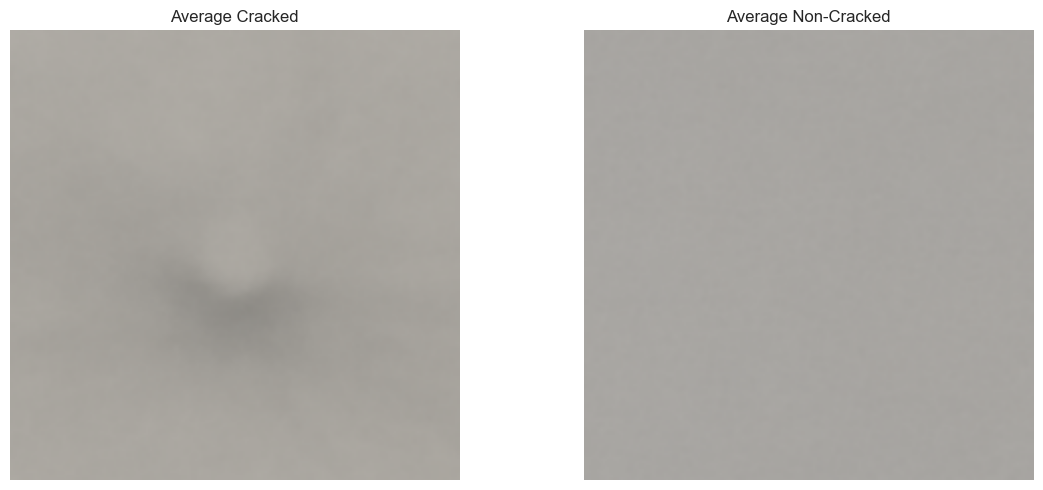

In [10]:
def avg_image(class_dir, n=500):
    rng = np.random.RandomState(42)
    files = rng.choice(os.listdir(class_dir), n, replace=False)
    s = np.zeros((227,227,3), dtype=np.float64)
    c = 0
    for f in files:
        try:
            s += np.array(Image.open(os.path.join(class_dir, f)).resize((227,227)))
            c += 1
        except: pass
    return (s/c).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(avg_image(CRACKED_DIR))
axes[0].set_title('Average Cracked')
axes[0].axis('off')
axes[1].imshow(avg_image(NON_CRACKED_DIR))
axes[1].set_title('Average Non-Cracked')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Custom PyTorch Dataset Class

In [11]:
class SurfaceCrackDataset(Dataset):
    def __init__(self, cracked_dir, non_cracked_dir, transform=None, max_samples=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        cf = sorted(os.listdir(cracked_dir))
        if max_samples: cf = cf[:max_samples]
        for f in cf:
            self.image_paths.append(os.path.join(cracked_dir, f))
            self.labels.append(1)
        nf = sorted(os.listdir(non_cracked_dir))
        if max_samples: nf = nf[:max_samples]
        for f in nf:
            self.image_paths.append(os.path.join(non_cracked_dir, f))
            self.labels.append(0)
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

### Define Transforms

In [12]:
IMAGE_SIZE = 227
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

### Train/Test Split (80/20)

In [13]:
full = SurfaceCrackDataset(CRACKED_DIR, NON_CRACKED_DIR, transform=train_transform)
print(f'Total: {len(full)}')
tr_size = int(0.8 * len(full))
te_size = len(full) - tr_size
tr_ds, te_ds = random_split(full, [tr_size, te_size], generator=torch.Generator().manual_seed(42))
te_ds.dataset.transform = test_transform
print(f'Train: {tr_size}, Test: {te_size}')

Total: 96092
Train: 76873, Test: 19219


### Create DataLoaders

In [14]:
BATCH_SIZE = 32
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train batches: {len(tr_loader)}, Test batches: {len(te_loader)}')
imgs, labs = next(iter(tr_loader))
print(f'Batch shape: {imgs.shape}')

Train batches: 2403, Test batches: 601
Batch shape: torch.Size([32, 3, 227, 227])


### Visualize a Transformed Batch

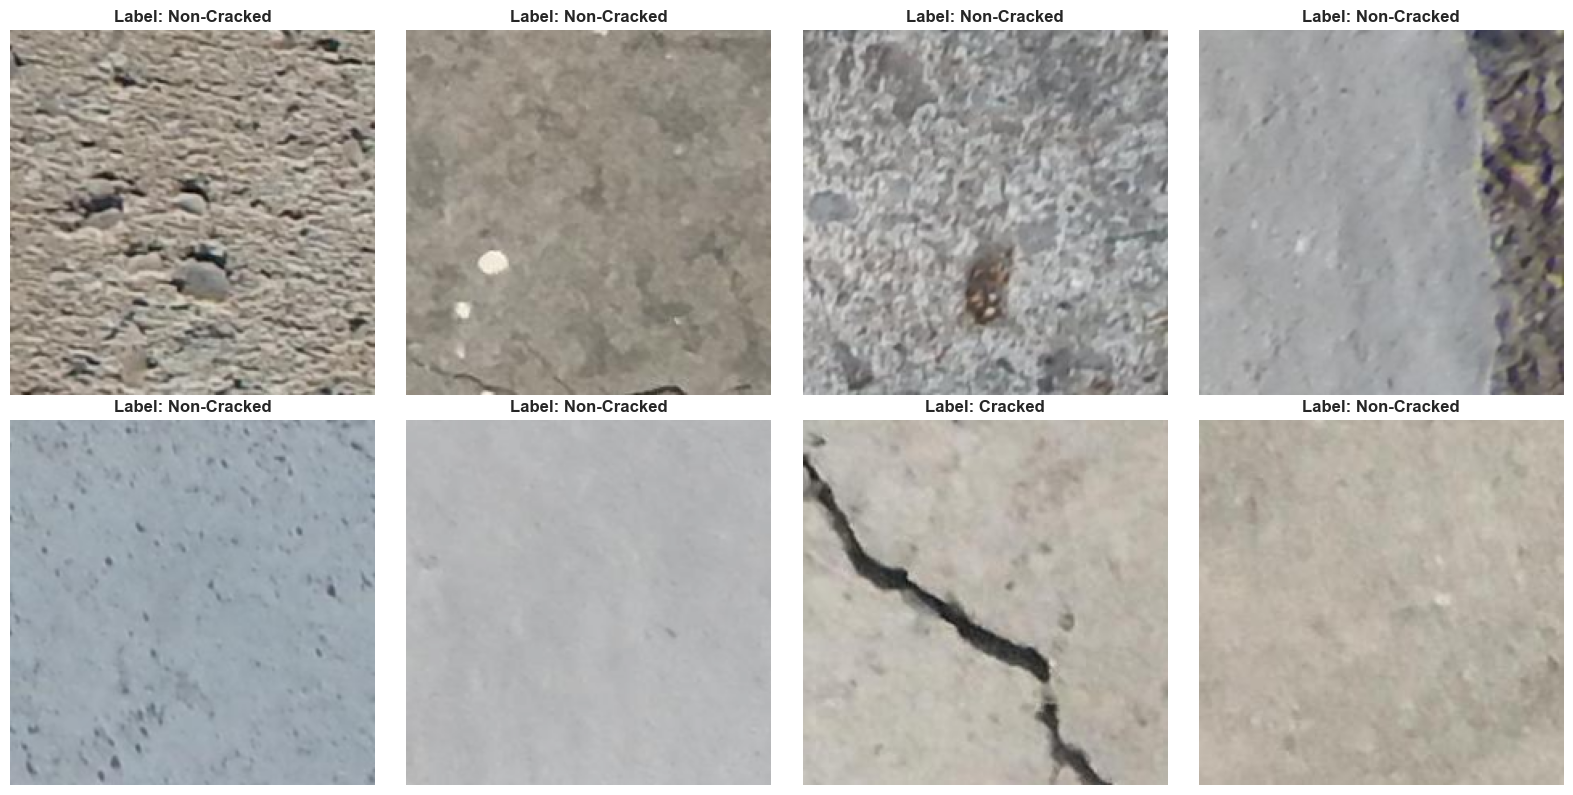

In [15]:
def show_batch(loader):
    imgs, labs = next(iter(loader))
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    fig, axes = plt.subplots(2, 4, figsize=(16,8))
    axes = axes.flatten()
    names = ['Non-Cracked', 'Cracked']
    for i in range(8):
        img = imgs[i].numpy().transpose(1,2,0)
        img = np.clip(std*img + mean, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f'Label: {names[labs[i].item()]}', fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
show_batch(tr_loader)

### Summary Table

In [16]:
cp = f'{n_cracked/total*100:.2f}%'
ncp = f'{n_non_cracked/total*100:.2f}%'
data = {
    'Metric': ['Total','Cracked','Non-Cracked','Cracked %','Non-Cracked %',
               'Size','Channels','Train','Test','Batch Size'],
    'Value': [total, n_cracked, n_non_cracked, cp, ncp,
              f'{IMAGE_SIZE}x{IMAGE_SIZE}','RGB (3)', tr_size, te_size, BATCH_SIZE]
}
print(pd.DataFrame(data).to_string(index=False))

       Metric   Value
        Total   96092
      Cracked   28484
  Non-Cracked   67608
    Cracked %  29.64%
Non-Cracked %  70.36%
         Size 227x227
     Channels RGB (3)
        Train   76873
         Test   19219
   Batch Size      32


### Save Metadata

In [17]:
import json
meta = {'cracked_dir': CRACKED_DIR, 'non_cracked_dir': NON_CRACKED_DIR,
        'image_size': IMAGE_SIZE, 'n_cracked': n_cracked, 'n_non_cracked': n_non_cracked,
        'train_size': tr_size, 'test_size': te_size, 'batch_size': BATCH_SIZE}
with open('data_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved data_metadata.json')
print('Data preparation complete!')

Saved data_metadata.json
Data preparation complete!
